In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.cluster import KMeans


# Cargar los datos

In [ ]:
carpeta_datos_generados= "C:/Users/X421/Desktop/beca iniciacion/python/datos_generados/"

G_secciones= ox.load_graphml((carpeta_datos_generados + "red_sociodemo_secciones.graphml"))

diff_entre_secciones= pd.read_csv((carpeta_datos_generados+"diferencias_entre_secciones.csv"))
df_sociodemo = pd.read_csv((carpeta_datos_generados+"seccion_censal_conINFO.csv"))

#para tener mapa de los barrios
mapa_barrio = gpd.read_file((carpeta_datos_generados+"barrios_geometria.shp"), engine= 'fiona')
mapa_distritos = gpd.read_file((carpeta_datos_generados+"distritos_geometria.shp"), engine= 'fiona')

Cannot find header.dxf (GDAL_DATA is not defined)


In [6]:
columnas_num=['SC_area', 'SC_perim', 'rend_brut', 'gini_idx', 'edat_mitj', 'supVIV_m2', 'n_ofic', 'n_viv',
              'n_com', 'n_ens_cul', 'pct_m2_v', 'renta_40', 'renta_160', 'tasa_paro',
              'edu_prim', 'edu_super', 'prop_extr', 'naci_bcn', 'med_prA', 'iqr_prA',]

for nodo, datos in G_secciones.nodes(data=True):
    for col in columnas_num:
        if col in datos:
            datos[col] = np.float32(datos[col])
            

for u, v, datos in G_secciones.edges(data=True):
    for col in ['dist_euclidiana', 'dist_ruta', 'dist_diff', 'shared_ratio_avg', 'pendiente_media_pct', 'desnivel_acumulado_m', 'shared_boundary_length']:
        if col in datos:
            datos[col] = np.float32(datos[col])

secc_nodes, secc_eges= ox.graph_to_gdfs(G_secciones)

display(secc_eges.head())
display(secc_nodes.head())



dist_euclidiana    dist_ruta      dist_ruta_red  \
u    v    key                                                    
1001 3025 0        4010.562012  4324.075195  4202.189231500603   
     3020 0         379.909454   426.199524  365.2973177925355   
     3019 0         483.920105   615.751831  514.2841970385424   
     1003 0         429.921448   744.050842   631.975938893082   
     1002 0         459.469421   946.303345  848.0529142654824   

                      extra_leg_m   dist_diff  shared_boundary_length  \
u    v    key                                                           
1001 3025 0    121.88585186969934  313.513031               94.313782   
     3020 0     60.90221079041078   46.290073              413.200134   
     3019 0    101.46764319372039  131.831741               39.943054   
     1003 0     112.0748750225725  314.129364              214.209824   
     1002 0      98.2504467046499  486.833954              287.421570   

              shared_ratio_orig shared_ratio_dest  shared_ratio_avg  \
u    v    key                                                         
1001 3025 0              0.0338            0.0021            0.0179   
     3020 0               0.148            0.2308            0.1894   
     3019 0              0.0143             0.037            0.0256   
     1003 0              0.0767            0.2506            0.1636   
     1002 0              0.1029            0.3206            0.2117   

               desnivel_acumulado_m  pendiente_media_pct  \
u    v    key                                              
1001 3025 0                     2.0                 0.05   
     3020 0                     2.0                 0.47   
     3019 0                     9.0                 1.46   
     1003 0                    11.0                 1.48   
     1002 0                     4.0                 0.42   

                                                        geometry  
u    v    key                                                     
1001 3025 0    LINESTRING (431168.008 4580658.854, 428571.386...  
     3020 0    LINESTRING (431168.008 4580658.854, 430963.53 ...  
     3019 0    LINESTRING (431168.008 4580658.854, 430684.561...  
     1003 0    LINESTRING (431168.008 4580658.854, 430771.944...  
     1002 0    LINESTRING (431168.008 4580658.854, 430936.187...

,x,y,codi_dist,nom_dist,codi_bar,nom_barri,SC_area,SC_perim,sec_cens,rend_brut,...,renta_40,renta_160,edu_prim,edu_super,prop_extr,naci_bcn,tasa_paro,med_prA,iqr_prA,geometry
osmid,,,,,,,,,,,,,,,,,,,,,
1001,431168.008045,4.580659e+06,1,Ciutat Vella,1,el Raval,2.186991e+05,2792.011475,1,17113.0,...,14.600000,16.700001,0.143251,0.415978,0.533279,0.273539,0.112084,14.199074,4.996995,POINT (431168.008 4580658.854)
3025,428571.385792,4.577602e+06,3,Sants-Montjuïc,12,la Marina del Prat Vermell,1.425234e+07,44188.273438,25,17334.0,...,10.400000,17.299999,0.185654,0.289733,0.245092,0.604997,0.125654,7.660453,4.040043,POINT (428571.386 4577602.359)
3020,430963.529800,4.580339e+06,3,Sants-Montjuïc,11,el Poble Sec,1.123530e+05,1790.043579,20,21396.0,...,10.800000,27.200001,0.149909,0.415905,0.347754,0.404326,0.077869,12.292420,3.398431,POINT (430963.53 4580338.666)
3019,430684.560734,4.580637e+06,3,Sants-Montjuïc,11,el Poble Sec,5.869209e+04,1078.202637,19,18311.0,...,10.500000,15.100000,0.123735,0.424125,0.469613,0.348066,0.086667,13.030620,4.709736,POINT (430684.561 4580637.468)
1003,430771.944091,4.580826e+06,1,Ciutat Vella,1,el Raval,4.058127e+04,854.911255,3,12707.0,...,23.299999,7.800000,0.204819,0.289533,0.530769,0.286095,0.132584,15.505265,5.439023,POINT (430771.944 4580826.083)


# Culstering de las basico

## Clustering de las caracterísitcas como tabular

In [7]:
caract_sociodemo=['rend_brut', 'gini_idx', 'edat_mitj', 'supVIV_m2', 'n_ofic', 'n_viv',
                  'n_com', 'n_ens_cul', 'pct_m2_v', 'renta_40', 'renta_160', 'tasa_paro',
                  'edu_prim', 'edu_super', 'prop_extr', 'naci_bcn', 'med_prA', 'iqr_prA']

df_sociodemo = secc_nodes[caract_sociodemo]

In [8]:
from sklearn.preprocessing import StandardScaler

df_sociodemo = df_sociodemo.dropna()

scaler = StandardScaler()
df_sociodemo_scaled = pd.DataFrame(
    scaler.fit_transform(df_sociodemo),
    index=df_sociodemo.index,
    columns=df_sociodemo.columns
)

### Para saber k

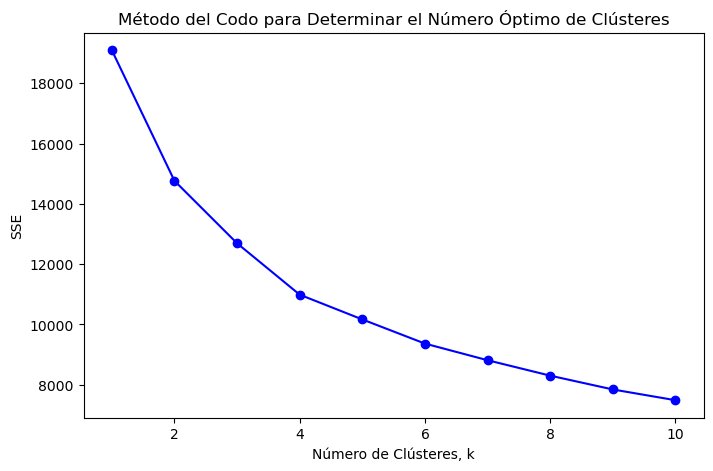

In [9]:
# Definir el rango de valores de k
k_range = range(1, 11)
sse = [] #lista para guardar los valores de SSE que vamos a graficar después

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=25, random_state=123)
    kmeans.fit(df_sociodemo_scaled)
    sse.append(kmeans.inertia_)  # inertia_ es el SSE para el modelo K-means

# Graficar los resultados
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, 'bo-')
plt.xlabel('Número de Clústeres, k')
plt.ylabel('SSE')
plt.title('Método del Codo para Determinar el Número Óptimo de Clústeres')
plt.show()

Para 2 clústeres, el promedio del coeficiente de Silueta es: 0.22135185205088215
Para 3 clústeres, el promedio del coeficiente de Silueta es: 0.22367493097485158
Para 4 clústeres, el promedio del coeficiente de Silueta es: 0.20940675465862624
Para 5 clústeres, el promedio del coeficiente de Silueta es: 0.16126639683641736
Para 6 clústeres, el promedio del coeficiente de Silueta es: 0.17314489926151616
Para 7 clústeres, el promedio del coeficiente de Silueta es: 0.15582298843633519
Para 8 clústeres, el promedio del coeficiente de Silueta es: 0.1590369746310856
Para 9 clústeres, el promedio del coeficiente de Silueta es: 0.15891269004280392
Para 10 clústeres, el promedio del coeficiente de Silueta es: 0.1592576691846946


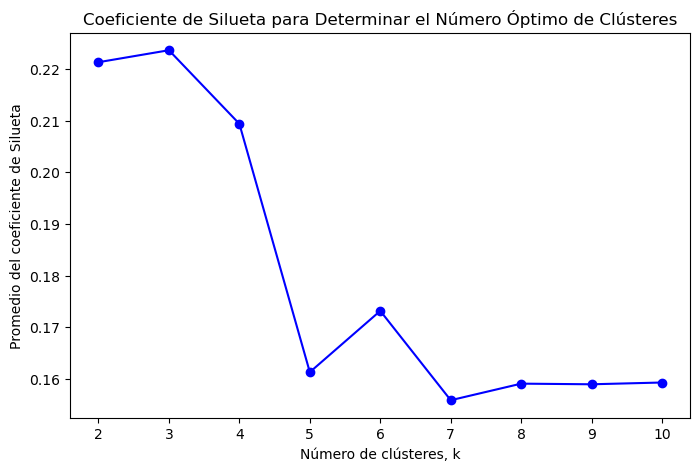

In [10]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

k_range = range(2, 11) #se debe empezar en 2

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init= 50, random_state=123)
    kmeans.fit(df_sociodemo_scaled)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(df_sociodemo_scaled, labels)
    silhouette_scores.append(silhouette_avg)
    print("Para", k, "clústeres, el promedio del coeficiente de Silueta es:", silhouette_avg)

# Graficar los resultados
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Número de clústeres, k')
plt.ylabel('Promedio del coeficiente de Silueta')
plt.title('Coeficiente de Silueta para Determinar el Número Óptimo de Clústeres')
plt.show()

### Aplicar k means

In [11]:
# Crear el modelo k-means con 3 clusters (ya que sabemos que hay 3 especies de flores en el conjunto de datos iris)
kmeans = KMeans(n_clusters=5, random_state=123, n_init=5, max_iter=300, algorithm='lloyd')

# Ajustar el modelo a los datos
y_km = kmeans.fit(df_sociodemo_scaled)

In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels = kmeans.labels_.astype('int')

inertia = kmeans.inertia_
silhouette = silhouette_score(df_sociodemo, labels)
davies_bouldin = davies_bouldin_score(df_sociodemo, labels)
calinski_harabasz = calinski_harabasz_score(df_sociodemo, labels)

cluster_sizes = pd.Series(labels).value_counts().sort_index()

print("Tamaño de cada cluster:")
print(cluster_sizes)
print("\nMétricas de calidad del clustering:")
print(f"Inercia (SSE): {inertia:.2f}")
print(f"Silhouette: {silhouette:.4f}")
print(f"Davies-Bouldin: {davies_bouldin:.4f}")
print(f"Calinski-Harabasz: {calinski_harabasz:.2f}")

print("\nComentarios:")
print("- Inercia: valores más bajos indican clusters más compactos, pero no es comparable entre diferentes valores de k.")
print("- Silhouette: rango [-1, 1]. Valores cercanos a 1 indican clusters bien separados; entre 0.25 y 0.5 es aceptable; por debajo de 0.25 indica agrupaciones débiles.")
print("- Davies-Bouldin: valores más bajos son mejores. Un valor cercano a 0 indica buena separación y compactación de clusters.")
print("- Calinski-Harabasz: valores más altos son mejores. No tiene un límite superior fijo, se usa para comparar diferentes configuraciones de clustering.")

Tamaño de cada cluster:
0    147
1    390
2    141
3    299
4     84
Name: count, dtype: int64

Métricas de calidad del clustering:
Inercia (SSE): 10166.38
Silhouette: 0.1854
Davies-Bouldin: 1.6677
Calinski-Harabasz: 981.77

Comentarios:
- Inercia: valores más bajos indican clusters más compactos, pero no es comparable entre diferentes valores de k.
- Silhouette: rango [-1, 1]. Valores cercanos a 1 indican clusters bien separados; entre 0.25 y 0.5 es aceptable; por debajo de 0.25 indica agrupaciones débiles.
- Davies-Bouldin: valores más bajos son mejores. Un valor cercano a 0 indica buena separación y compactación de clusters.
- Calinski-Harabasz: valores más altos son mejores. No tiene un límite superior fijo, se usa para comparar diferentes configuraciones de clustering.


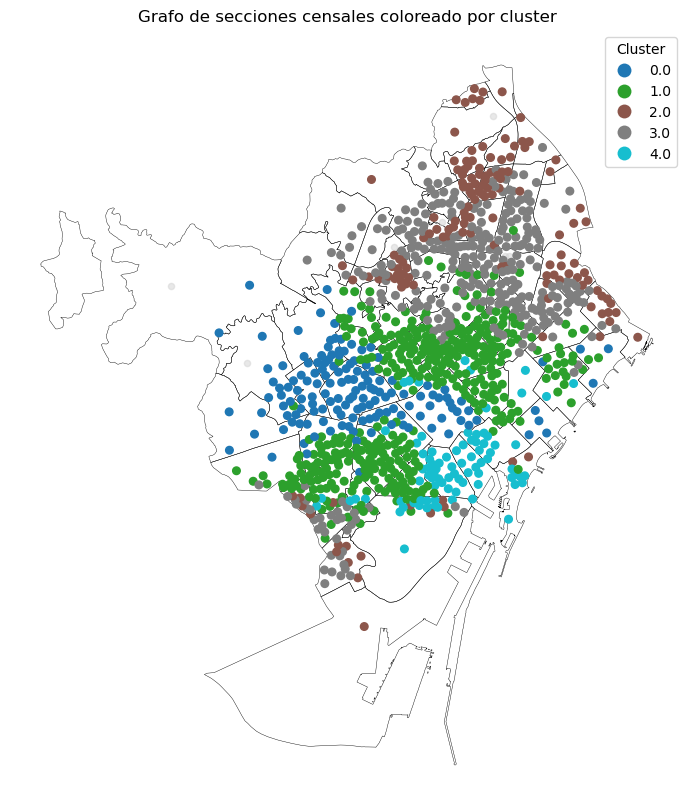

In [13]:
node_clusters = pd.Series(labels, index=df_sociodemo.index, name='cluster_sociodemo')
secc_nodes = secc_nodes.join(node_clusters, how='left')

ax = mapa_barrio.plot(
    figsize=(10,10),
    facecolor="none",
    edgecolor="black",
    linewidth=0.3
    )

secc_nodes[secc_nodes['cluster_sociodemo'].isna()].plot(
    ax=ax, color='lightgray', markersize=20, alpha=0.5, label='sin cluster'
)

secc_nodes[secc_nodes['cluster_sociodemo'].notna()].plot(
    ax=ax,
    column='cluster_sociodemo',
    cmap='tab10',
    markersize=30,
    legend=True,
    categorical=True,
    legend_kwds={'title': 'Cluster'}
)


ax.set_title("Grafo de secciones censales coloreado por cluster")
ax.axis('off')
plt.show()

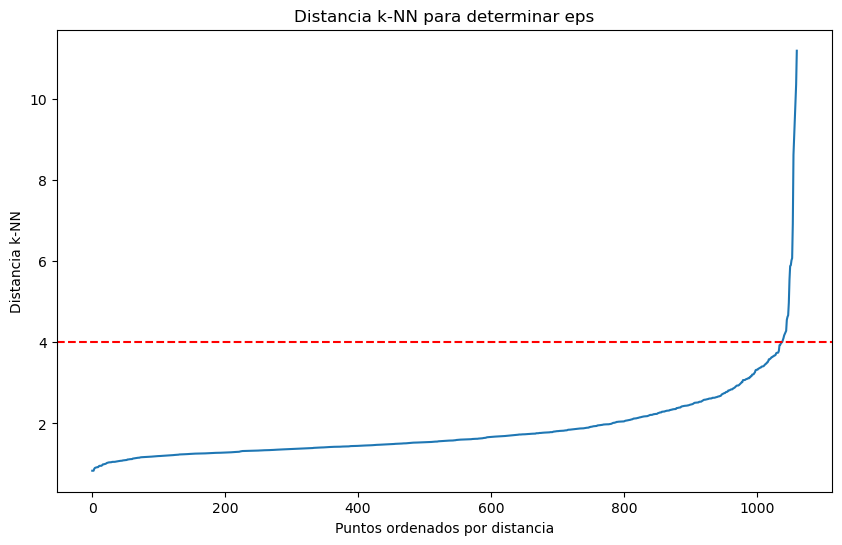

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


# Definir el número de vecinos
k = 4  # minPts generalmente es elegido como 4 o mayor dependiendo de la densidad esperada

# Calcular la distancia a los k-ésimos vecinos más cercanos
nbrs = NearestNeighbors(n_neighbors=10).fit(df_sociodemo_scaled)
distances, indices = nbrs.kneighbors(df_sociodemo_scaled)

# Ordenar las distancias de menor a mayor
distances = np.sort(distances[:, k-1], axis=0)

# Graficar la distancia a los k-ésimos vecinos más cercanos
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.ylabel('Distancia k-NN')
plt.xlabel('Puntos ordenados por distancia')
plt.title('Distancia k-NN para determinar eps')

# Una línea horizontal (y=0.3) ayuda a visualizar un posible valor de eps
plt.axhline(y=4, color='r', linestyle='--')
plt.show()

In [12]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=4, min_samples=3)

# Ajustamos el modelo a los datos
y_dbs = dbscan.fit_predict(df_sociodemo_scaled)

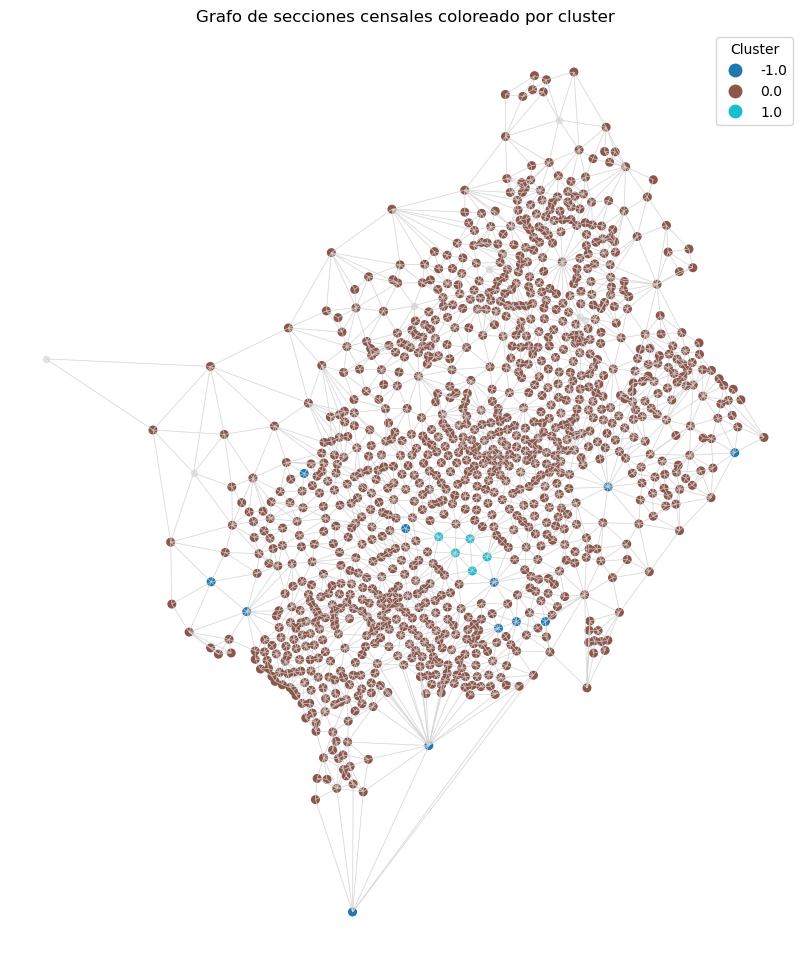

In [13]:
node_clusters = pd.Series(y_dbs, index=df_sociodemo.index, name='cluster')
secc_nodes_cluster = secc_nodes.copy()
secc_nodes_cluster = secc_nodes_cluster.join(node_clusters, how='left')

fig, ax = plt.subplots(figsize=(12, 12))
secc_eges.plot(ax=ax, color='lightgray', linewidth=0.5, alpha=0.6)

secc_nodes_cluster[secc_nodes_cluster['cluster'].isna()].plot(
    ax=ax, color='lightgray', markersize=20, alpha=0.5, label='sin cluster'
)

secc_nodes_cluster[secc_nodes_cluster['cluster'].notna()].plot(
    ax=ax,
    column='cluster',
    cmap='tab10',
    markersize=30,
    legend=True,
    categorical=True,
    legend_kwds={'title': 'Cluster'}
)

ax.set_title("Grafo de secciones censales coloreado por cluster")
ax.axis('off')
plt.show()

## Detección de comunidades (grafo)

In [14]:
df_edges= secc_eges.copy()

In [15]:
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

df_edges["dist_ruta_norm"] = minmax(df_edges["dist_ruta"])
df_edges["desnivel_acum_norm"] = minmax(df_edges["desnivel_acumulado_m"])
df_edges["pendiente_media_norm"] = minmax(df_edges["pendiente_media_pct"])

In [16]:
df_edges["coste_movilidad"] = (
    0.6 * df_edges["dist_ruta_norm"]
    + 0.1 * df_edges["desnivel_acum_norm"]
    + 0.3 * df_edges["pendiente_media_norm"])

df_edges["peso_movilidad"] = 1 / (1 + df_edges["coste_movilidad"])
df_edges["peso_final"] = df_edges["peso_movilidad"] * df_edges['shared_ratio_avg']

In [17]:
G_edge = nx.Graph()

for _, row in df_edges.reset_index().iterrows():
    G_edge.add_edge(
        int(row["u"]),
        int(row["v"]),
        weight= row["peso_final"])   


In [18]:
import igraph as ig
import leidenalg
import networkx as nx

# Extraer aristas con pesos
edges = [
    (str(u), str(v), d["weight"])
    for u, v, d in G_edge.edges(data=True)
]

# Crear grafo igraph
g_ig = ig.Graph.TupleList(
    edges,
    weights=True,
    directed=False
)

g_no_peso = ig.Graph.TupleList(
    edges,
    weights=False,
    directed=False
)

In [19]:
partition = leidenalg.find_partition(
    g_ig,
    leidenalg.RBConfigurationVertexPartition,
    weights="weight",
    resolution_parameter=0.2,
    n_iterations=-1,
    seed=12
)


communities = {
    node: comm
    for node, comm in zip(g_ig.vs["name"], partition.membership)
}


In [20]:
community_counts = pd.Series(partition.membership).value_counts().sort_index()
print(community_counts)

0    278
1    213
2    197
3    153
4    130
5     97
Name: count, dtype: int64


In [21]:
mask = secc_nodes["SC"].astype(int) == secc_nodes.index
print("Coinciden todos:", mask.all())
print("Número de filas distintas:", int((~mask).sum()))
secc_nodes.loc[~mask, ["SC"]].head(20)

Coinciden todos: True
Número de filas distintas: 0


,SC
osmid,


In [22]:
community_dict = {v["name"]: partition.membership[v.index] for v in g_ig.vs}
secc_nodes["community_leiden"] = secc_nodes.index.astype(str).map(community_dict)


print("NaN en comunidad_id:", secc_nodes["community_leiden"].isna().sum())

# Para ver qué claves faltan
missing = set(secc_nodes.index.astype(str)) - set(community_dict)
print("Claves sin comunidad:", sorted(list(missing))[:20])

NaN en comunidad_id: 0
Claves sin comunidad: []


In [23]:
partition_2 = leidenalg.find_partition(
    g_no_peso,
    leidenalg.RBConfigurationVertexPartition,
    resolution_parameter=0.2,
    n_iterations=-1,
    seed=12
)


communities_2 = {
    node: comm
    for node, comm in zip(g_ig.vs["name"], partition.membership)
}

community_dict = {v["name"]: partition_2.membership[v.index] for v in g_ig.vs}
secc_nodes["community_leiden_sin_peso"] = secc_nodes.index.astype(str).map(community_dict)


print("NaN en comunidad_id:", secc_nodes["community_leiden_sin_peso"].isna().sum())

# Para ver qué claves faltan
missing = set(secc_nodes.index.astype(str)) - set(community_dict)
print("Claves sin comunidad:", sorted(list(missing))[:20])


NaN en comunidad_id: 0
Claves sin comunidad: []


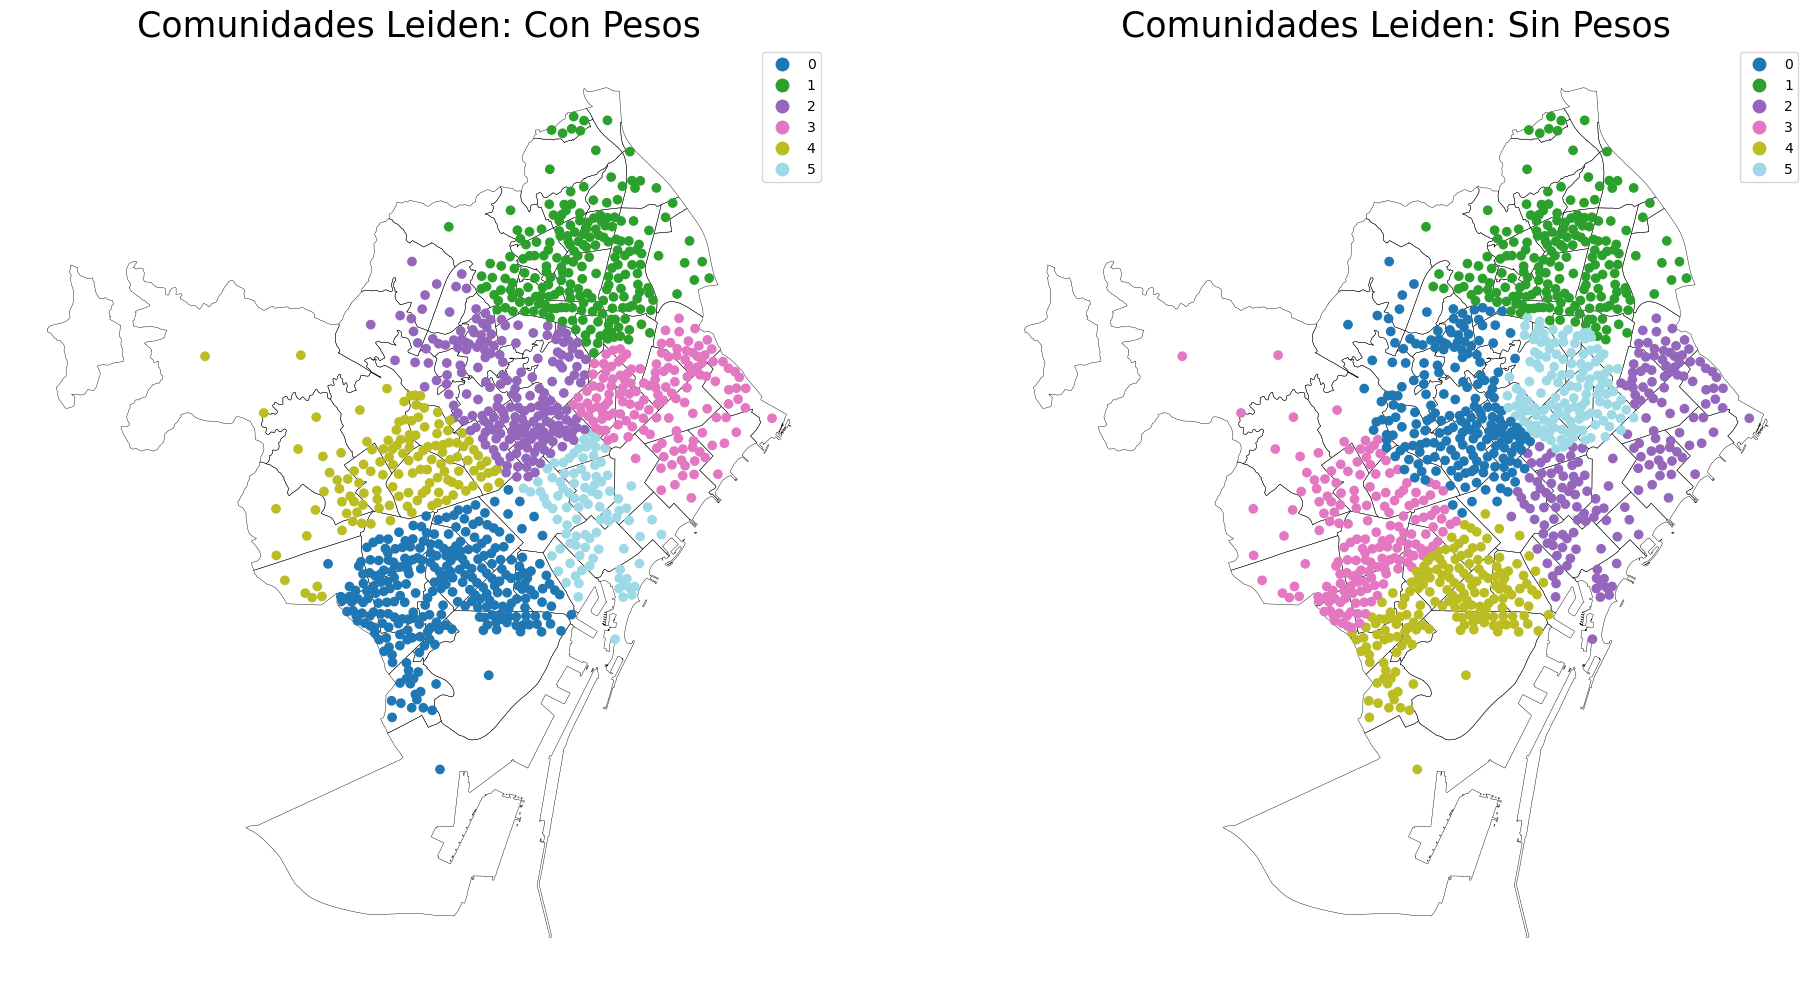

In [24]:
# 1. Crear la figura y los ejes
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# 2. Definir las columnas a pintar y sus títulos
columnas = ["community_leiden", "community_leiden_sin_peso"]
titulos = ["Con Pesos", "Sin Pesos"]

# 3. Iterar simultáneamente sobre los ejes, las columnas y los títulos
for ax, col, titulo in zip(axes, columnas, titulos):
    
    # Dibujar el mapa base
    mapa_barrio.plot(
        ax=ax, 
        facecolor="none", 
        edgecolor="black", 
        linewidth=0.3
    )
    
    # Dibujar los nodos
    secc_nodes.plot(
        column=col,
        categorical=True,
        cmap="tab20",           # GeoPandas se encarga de repartir los colores
        legend=True,
        missing_kwds={"color": "black"},
        ax=ax
    )
    
    # Ajustes finales del eje
    ax.set_title(f"Comunidades Leiden: {titulo}", fontsize=25)
    ax.axis("off")

# 4. Mostrar el mapa
plt.tight_layout()
plt.show()

## Comparación Leiden y sociodemografico

In [25]:
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print(f"ARI distrito vs Leiden:{adjusted_rand_score(secc_nodes['codi_dist'], secc_nodes['community_leiden'])}")
print(f"NMI distrito vs Leiden:{normalized_mutual_info_score(secc_nodes['codi_dist'], secc_nodes['community_leiden'])}")

# máscara por filas: ambas columnas deben existir
mask = secc_nodes[["community_leiden", "cluster_sociodemo"]].notna().all(axis=1)

# convertir de forma segura a numérico
labels_A = pd.to_numeric(secc_nodes.loc[mask, "community_leiden"], errors="coerce")
labels_B = pd.to_numeric(secc_nodes.loc[mask, "cluster_sociodemo"], errors="coerce")

# eliminar posibles NaN restantes antes de pasar a int
valid = labels_A.notna() & labels_B.notna()
labels_A = labels_A.loc[valid].astype(int).to_numpy()
labels_B = labels_B.loc[valid].astype(int).to_numpy()


# 1. Calcular ARI
ari = adjusted_rand_score(labels_A, labels_B)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

# 2. Calcular NMI
nmi = normalized_mutual_info_score(labels_A, labels_B)
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

# 3. Generar Matriz de Contingencia para ver los "cruces"
matriz_cruce = pd.crosstab(labels_B, labels_A, colnames=['Clustering Modularidad'], rownames=['Clustering Sociodemográfico'])
print("\nMatriz de Contingencia:")
display(matriz_cruce)

ARI distrito vs Leiden:0.4796831852236029
NMI distrito vs Leiden:0.6718999829956056
Adjusted Rand Index (ARI): 0.1695
Normalized Mutual Information (NMI): 0.2756

Matriz de Contingencia:


Clustering Modularidad,0,1,2,3,4,5
Clustering Sociodemográfico,,,,,,
0,29,0,3,4,95,16
1,152,3,106,52,30,47
2,16,78,19,26,0,2
3,36,128,66,68,1,0
4,45,0,2,3,2,32


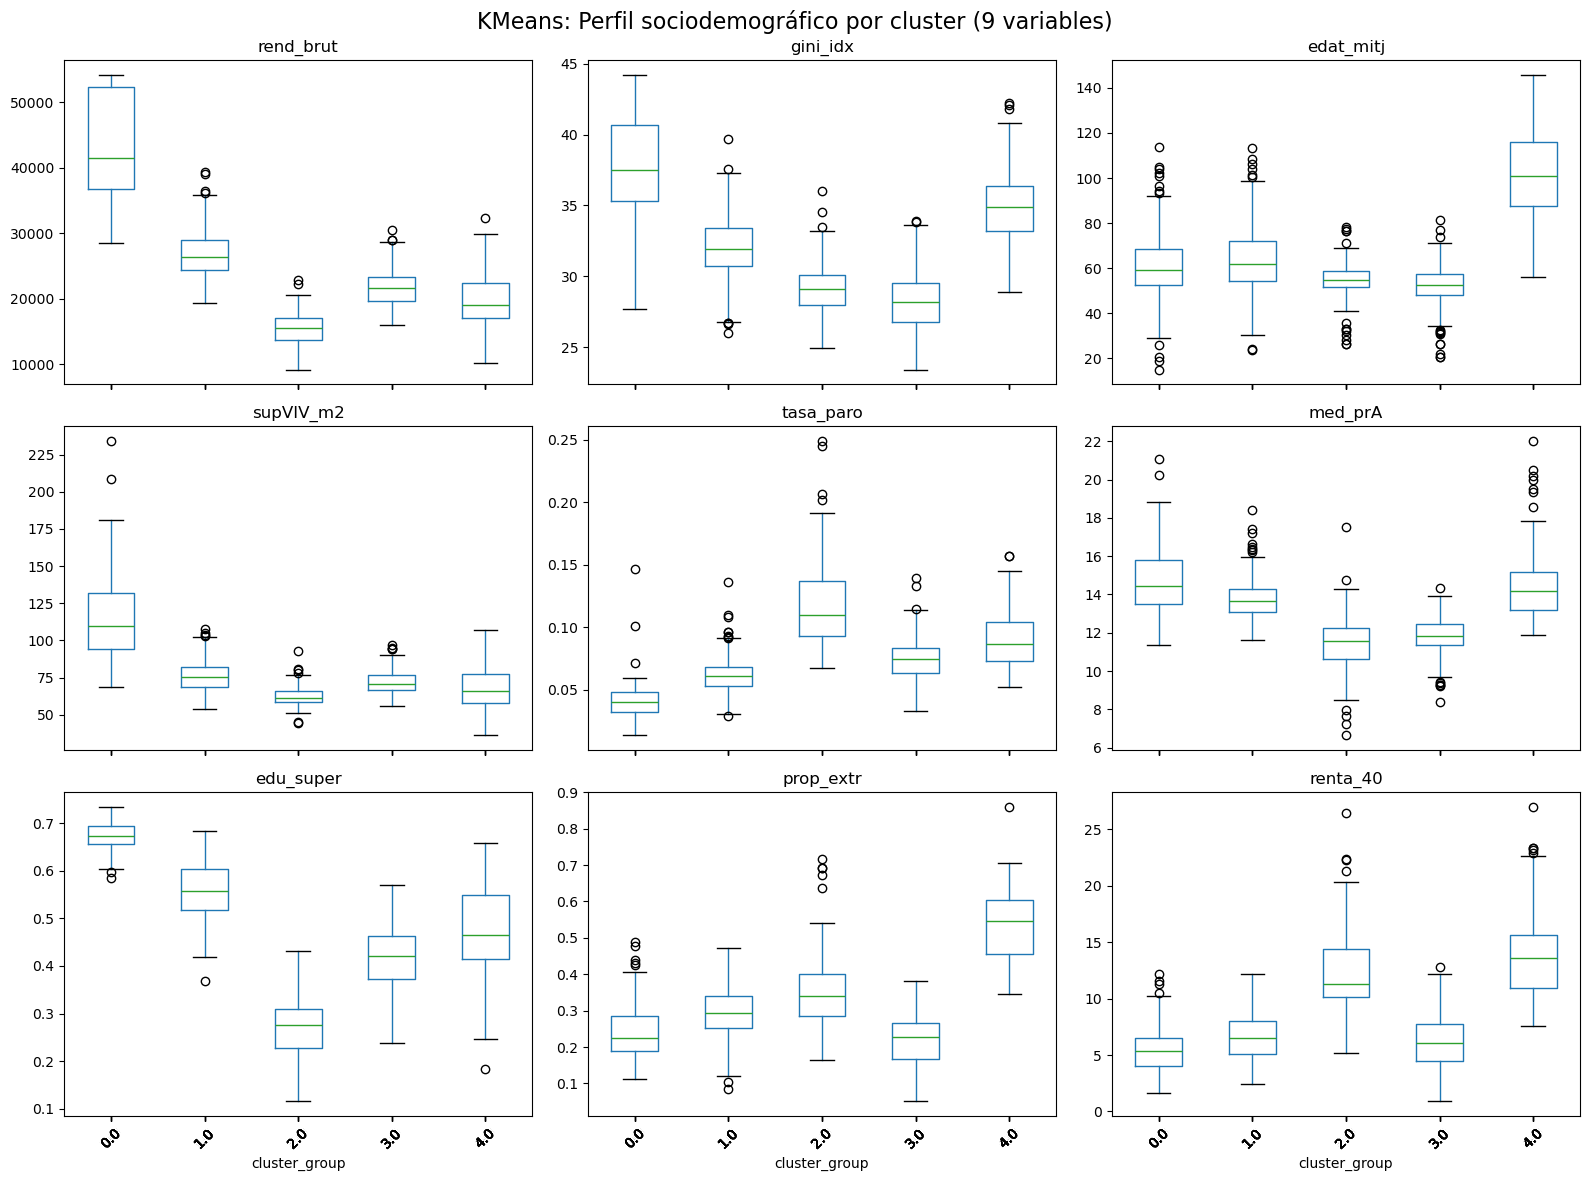

In [26]:
# --- 1) Variables a visualizar (9 variables sociodemográficas) ---
plot_features = [
    "rend_brut",   # Renta bruta
    "gini_idx",    # Índice de Gini
    "edat_mitj",   # Edad media
    "supVIV_m2",   # Superficie de vivienda
    "tasa_paro",   # Tasa de paro
    "med_prA",    # Educación primaria
    "edu_super",   # Educación superior
    "prop_extr",   # Proporción de extranjeros
    "renta_40"     # Proporción de renta baja (o similar)
]

# ESTA ES LA LÍNEA QUE FALTABA: Transforma y limpia los datos
feat_raw = secc_nodes[caract_sociodemo].apply(pd.to_numeric, errors="coerce").dropna()

# --- 3) Función para los boxplots ---
def boxplot_sociodemo(labels_series, title):
    df_plot = feat_raw[plot_features].copy()
    labels = labels_series.reindex(df_plot.index)

    # Formateo de las etiquetas de los clusters
    if pd.api.types.is_numeric_dtype(labels):
        labels = pd.to_numeric(labels, errors="coerce")
    else:
        labels = labels.astype("category")

    df_plot["cluster_group"] = labels
    df_plot = df_plot.dropna(subset=["cluster_group"])

    # Generación de los boxplots (3 filas x 3 columnas)
    axes = df_plot.boxplot(
        by="cluster_group",
        column=plot_features,
        layout=(3, 3),      
        figsize=(16, 12),   
        sharey=False,
        rot=45,
    )
    
    # Limpieza visual (quitar las líneas de grid)
    if isinstance(axes, np.ndarray):
        for ax in axes.ravel():
            if ax is not None:
                ax.grid(False)
    else:
        axes.grid(False)
        
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


# --- 4) Generar el boxplot para KMeans ---
boxplot_sociodemo(secc_nodes["cluster_sociodemo"], "KMeans: Perfil sociodemográfico por cluster (9 variables)")

Metricas cruzadas (tabular + modularidad):


,silhouette,davies_bouldin,calinski_harabasz,n,k,modularity
clustering,,,,,,
kmeans,0.159762,1.524833,231.935840,1061,5,0.478179
leiden,-0.030252,4.441550,69.561611,1061,6,0.774077


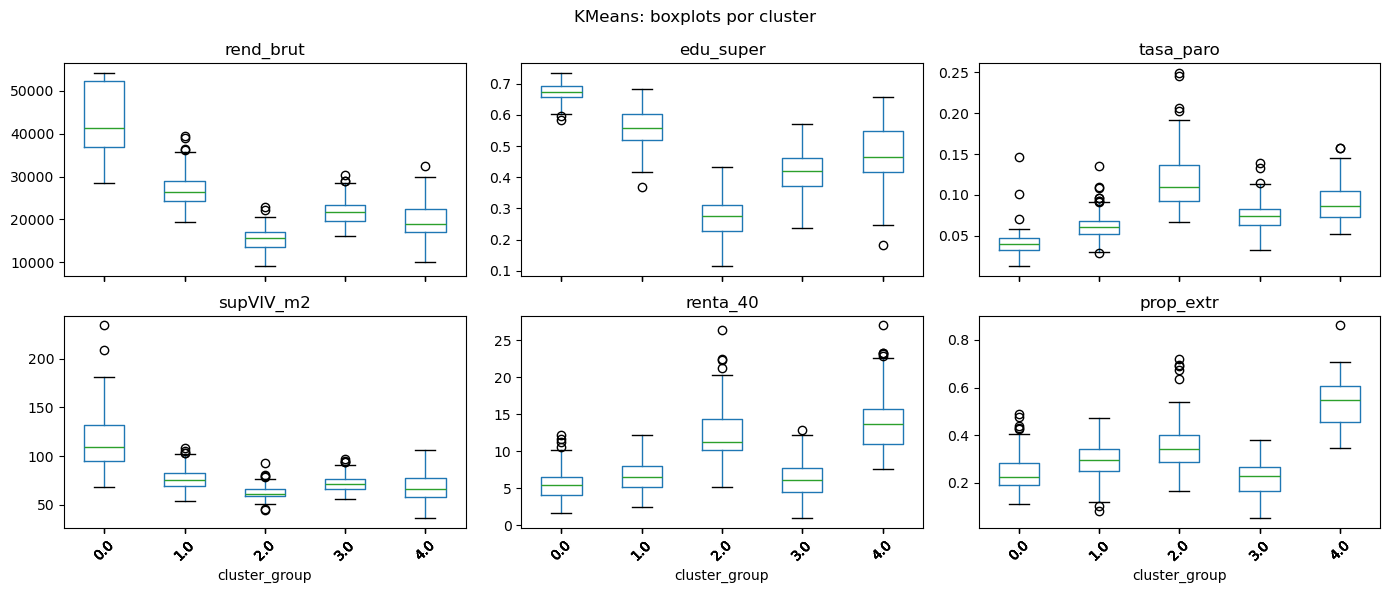

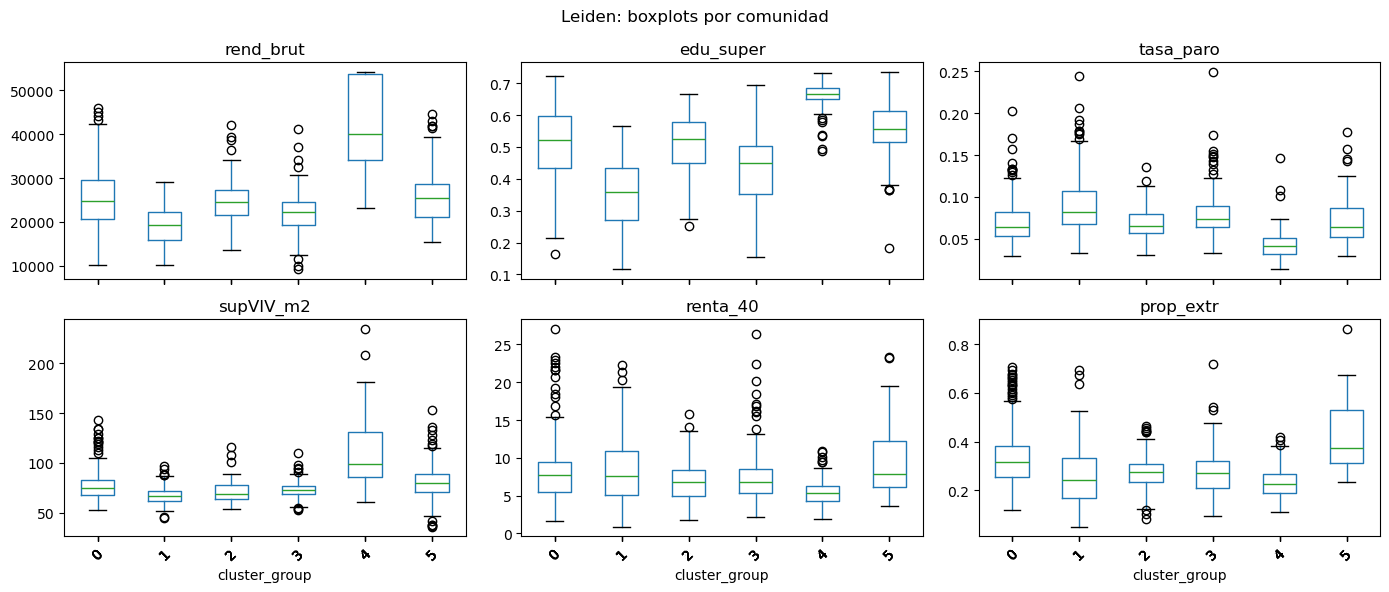

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --- 1) Preparar features tabulares ---
caract_sociodemo = [
    "rend_brut", "gini_idx", "edat_mitj", "supVIV_m2", "n_ofic", "n_viv",
    "n_com", "n_ens_cul", "pct_m2_v", "renta_40", "renta_160", "tasa_paro",
    "edu_prim", "edu_super", "prop_extr", "naci_bcn", "med_prA", "iqr_prA",
]

feat_raw = secc_nodes[caract_sociodemo].apply(pd.to_numeric, errors="coerce").dropna()
X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(feat_raw),
    index=feat_raw.index,
    columns=feat_raw.columns,
)


def align_X_labels(X, labels_series):
    labels = labels_series.reindex(X.index)
    if pd.api.types.is_numeric_dtype(labels):
        labels_num = pd.to_numeric(labels, errors="coerce")
        valid = labels_num.notna()
        labels_out = labels_num[valid].astype(int)
    else:
        labels_cat = labels.astype("category")
        codes = labels_cat.cat.codes
        valid = codes >= 0
        labels_out = codes[valid].astype(int)
    X_out = X.loc[valid]
    return X_out, labels_out.to_numpy()


def compute_tabular_metrics(X, labels):
    uniq = np.unique(labels)
    if len(uniq) < 2 or len(labels) <= len(uniq):
        return {
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
            "n": int(len(labels)),
            "k": int(len(uniq)),
        }
    return {
        "silhouette": float(silhouette_score(X, labels)),
        "davies_bouldin": float(davies_bouldin_score(X, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X, labels)),
        "n": int(len(labels)),
        "k": int(len(uniq)),
    }


def compute_modularity(G, labels_series):
    if G is None or G.number_of_edges() == 0:
        return np.nan
    labels = labels_series.dropna().copy()
    if labels.empty:
        return np.nan
    try:
        labels.index = labels.index.astype(int)
    except Exception:
        pass
    labels = labels[labels.index.isin(G.nodes)]
    if labels.empty:
        return np.nan
    communities = [set(group.index) for _, group in labels.groupby(labels)]
    if len(communities) < 2:
        return np.nan
    edge_example = next(iter(G.edges(data=True)), None)
    if edge_example is None:
        return np.nan
    weight_attr = "weight" if "weight" in edge_example[2] else None
    return float(
        nx.algorithms.community.quality.modularity(
            G.subgraph(labels.index),
            communities,
            weight=weight_attr,
        )
    )


# --- 2) Calcular metricas (silhouette/DB/CH) para KMeans y Leiden ---
X_k, labels_k = align_X_labels(X_scaled, secc_nodes["cluster_sociodemo"])
X_l, labels_l = align_X_labels(X_scaled, secc_nodes["community_leiden"])

metrics_k = compute_tabular_metrics(X_k, labels_k)
metrics_l = compute_tabular_metrics(X_l, labels_l)

# --- 3) Modularidad (metrica de grafo) para ambos clusterings ---
G_mod = G_edge if "G_edge" in globals() else None
if G_mod is None and "G_secciones" in globals():
    print("Aviso: G_edge no encontrado. Usando G_secciones sin pesos para modularidad.")
    G_mod = G_secciones

mod_k = compute_modularity(G_mod, secc_nodes["cluster_sociodemo"]) if G_mod is not None else np.nan
mod_l = compute_modularity(G_mod, secc_nodes["community_leiden"]) if G_mod is not None else np.nan

df_metrics = pd.DataFrame(
    [
        {"clustering": "kmeans", **metrics_k, "modularity": mod_k},
        {"clustering": "leiden", **metrics_l, "modularity": mod_l},
    ]
).set_index("clustering")

print("Metricas cruzadas (tabular + modularidad):")
display(df_metrics)

# --- 4) Boxplots para inspeccionar perfiles de clusters ---
plot_features = [
    "rend_brut",
    "edu_super",
    "tasa_paro",
    "supVIV_m2",
    "renta_40",
    "prop_extr",
]


def boxplot_by_cluster(labels_series, title, top_n=None):
    df_plot = feat_raw[plot_features].copy()
    labels = labels_series.reindex(df_plot.index)

    if pd.api.types.is_numeric_dtype(labels):
        labels = pd.to_numeric(labels, errors="coerce")
    else:
        labels = labels.astype("category")

    if top_n is not None:
        top_vals = labels.value_counts().head(top_n).index
        labels = labels.where(labels.isin(top_vals), other="otros")

    df_plot["cluster_group"] = labels
    df_plot = df_plot.dropna(subset=["cluster_group"])

    axes = df_plot.boxplot(
        by="cluster_group",
        column=plot_features,
        layout=(2, 3),
        figsize=(14, 6),
        sharey=False,
        rot=45,
    )
    if isinstance(axes, np.ndarray):
        for ax in axes.ravel():
            if ax is not None:
                ax.grid(False)
    else:
        axes.grid(False)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


boxplot_by_cluster(secc_nodes["cluster_sociodemo"], "KMeans: boxplots por cluster")
boxplot_by_cluster(
    secc_nodes["community_leiden"],
    "Leiden: boxplots por comunidad",
    top_n=10,
)


### Ver en mapa

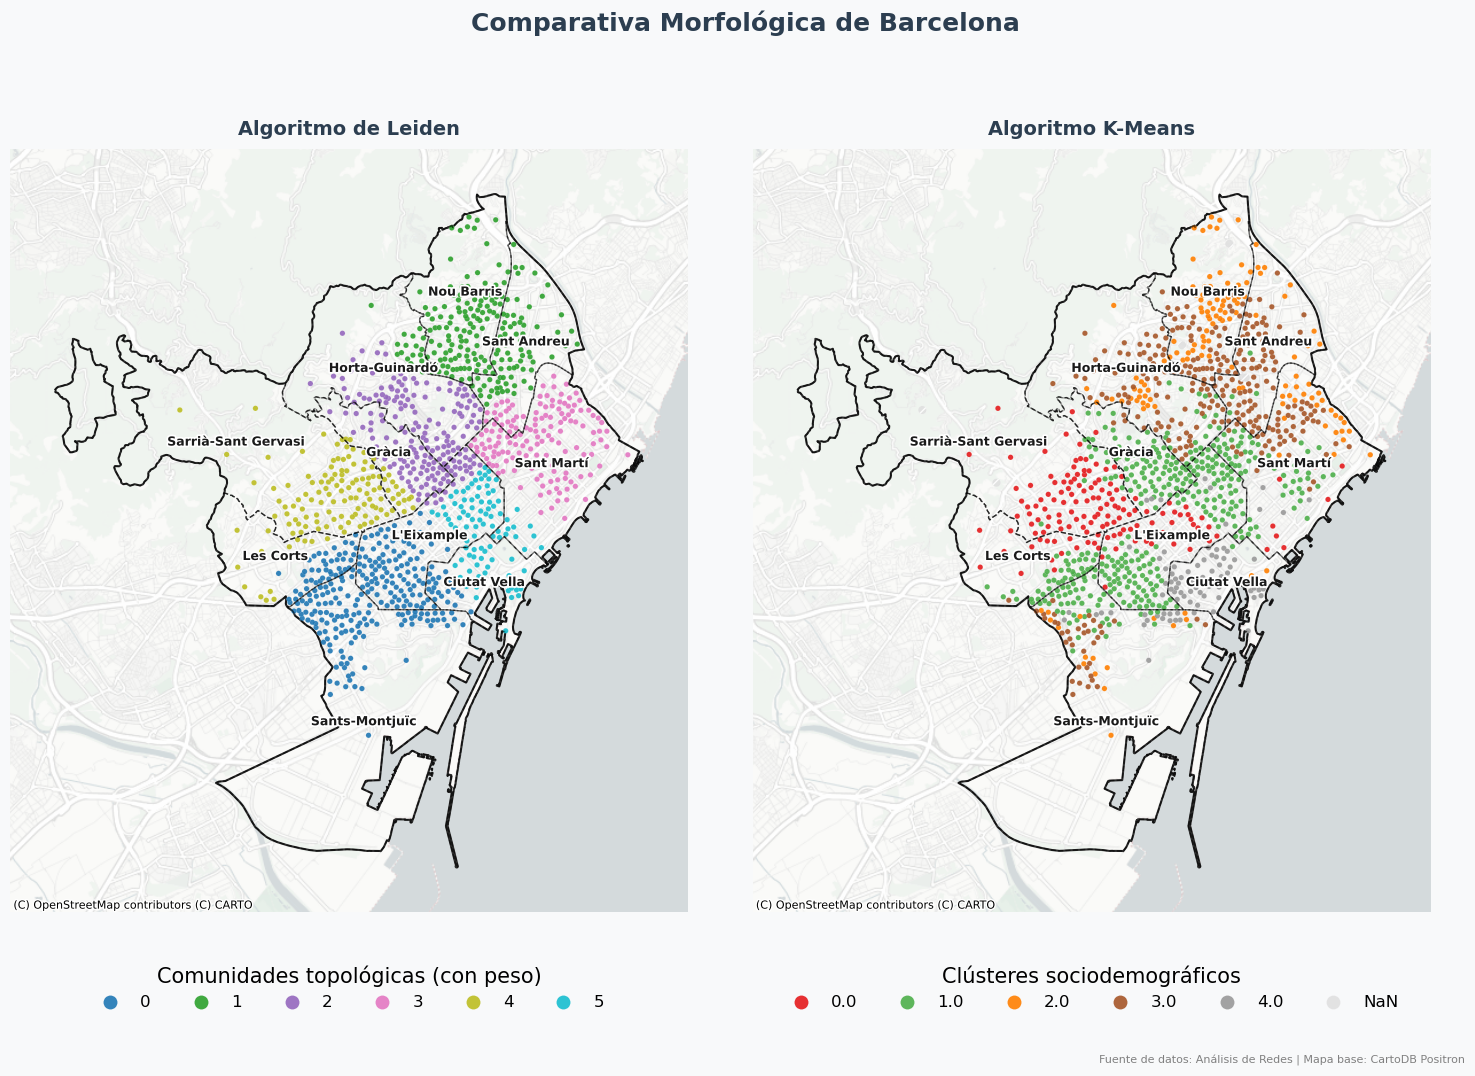

In [30]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
from shapely.geometry import box
import matplotlib.patheffects as pe

# ==========================================
# 0. PREPARACIÓN
# ==========================================
secc_nodes_plot = secc_nodes.to_crs(epsg=3857)
gdf_distritos_plot = mapa_distritos.to_crs(epsg=3857)

# 1. Crear figura ajustada para un documento de Word (14x7 pulgadas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 11), facecolor="#f8f9fa")

# ==========================================
# GEOMETRÍA COMÚN
# ==========================================
silueta_bcn = gdf_distritos_plot.geometry.union_all()
xmin, ymin, xmax, ymax = silueta_bcn.bounds

margen = 20000 
caja_gigante = box(xmin - margen, ymin - margen, xmax + margen, ymax + margen)
mascara_exterior = caja_gigante.difference(silueta_bcn)

# ==========================================
# CONFIGURACIÓN
# ==========================================
mapas_config = [
    {
        "ax": ax1, 
        "columna": "community_leiden", 
        "titulo": "Algoritmo de Leiden",
        "titulo_leyenda": "Comunidades topológicas (con peso)"
    },
    {
        "ax": ax2, 
        "columna": "cluster_sociodemo", 
        "titulo": "Algoritmo K-Means",
        "titulo_leyenda": "Clústeres sociodemográficos"
    }
]

# ==========================================
# BUCLE DE RENDERIZADO
# ==========================================
i=0
for mapa in mapas_config:
    i+=1
    ax = mapa["ax"]
    col = mapa["columna"]
    txt_titulo = mapa["titulo"]
    txt_leyenda = mapa["titulo_leyenda"]

    # Borde exterior rígido de la ciudad (línea un poco más fina)
    gpd.GeoSeries([silueta_bcn], crs=3857).boundary.plot(
        ax=ax,
        color="#2b2b2b",
        linewidth=1.5,
        zorder=1.6
    )

    # Capa 2: Datos de Clustering
    secc_nodes_plot.plot(
        column=col,
        categorical=True,
        cmap="tab10" if i==1 else "Set1",     
        legend=True,
        markersize=15, # Puntos reducidos proporcionalmente al nuevo figsize
        legend_kwds={
            "title": txt_leyenda,
            "title_fontsize": 15,
            "fontsize": 12,
            "frameon": False,        
            "bbox_to_anchor": (0.5, -0.05),
            "loc": "upper center",          
            "ncol": 6 # Puesto a 6 para que no ocupe tanto espacio horizontal
        },
        ax=ax,
        alpha=0.9,       
        edgecolor="white",
        linewidth=0.1,
        missing_kwds={"color": "#e0e0e0", "hatch": "///"}, 
        zorder=2
    )

    # Capa 3: Límites internos de distritos
    gdf_distritos_plot.boundary.plot(
        ax=ax,
        color="black",    
        linewidth=1.0,    
        linestyle="--",   
        zorder=10,
        alpha=0.6
    )

    # Etiquetas de distritos
    for x, y, label in zip(gdf_distritos_plot.geometry.centroid.x, 
                           gdf_distritos_plot.geometry.centroid.y, 
                           gdf_distritos_plot["nom_dist"]):
        ax.text(x, y, label, 
                fontsize=9, # Letra más pequeña para que quepa bien en el nuevo lienzo
                fontweight="bold", 
                color="#1a1a1a", 
                ha="center", 
                va="center",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
                zorder=11)

    # Capa 1: Mapa base
    ctx.add_basemap(
        ax, 
        source=ctx.providers.CartoDB.PositronNoLabels,
        alpha=1,
        zorder=1
    )

    # Títulos individuales
    ax.set_title(txt_titulo, fontsize=14, fontweight="bold", color="#2c3e50", pad=10)
    ax.axis("off")
    ax.set_xlim(xmin - 1500, xmax + 1500)
    ax.set_ylim(ymin - 1500, ymax + 1500)

# ==========================================
# AJUSTES GLOBALES
# ==========================================
fig.suptitle("Comparativa Morfológica de Barcelona", 
             fontsize=18, 
             fontweight="bold", 
             color="#2c3e50", 
             y=0.98)

fig.text(0.98, 0.02, "Fuente de datos: Análisis de Redes | Mapa base: CartoDB Positron",
         fontsize=8, color='gray', ha='right', va='bottom')

# Ajuste fino de márgenes
plt.tight_layout(rect=[0, 0.10, 1, 0.95]) 

plt.show()

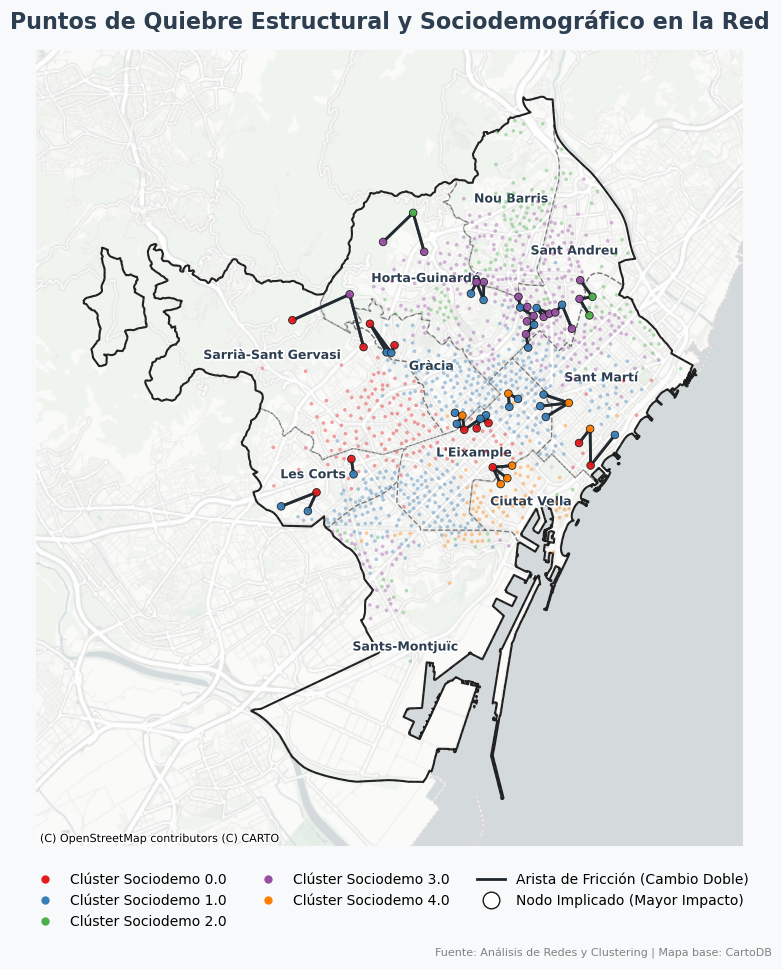

In [31]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
from shapely.geometry import box
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# ==========================================
# 0. PREPARACIÓN Y FILTRADO (Soporte MultiIndex u,v,key)
# ==========================================
secc_nodes_plot = secc_nodes.to_crs(epsg=3857)
gdf_distritos_plot = mapa_distritos.to_crs(epsg=3857)

# Aplanamos las aristas para extraer u y v
df_edges_flat = df_edges.reset_index()

# Mapeamos los atributos de origen (u) y destino (v)
df_edges_flat['s_leiden'] = df_edges_flat['u'].map(secc_nodes_plot['community_leiden'])
df_edges_flat['t_leiden'] = df_edges_flat['v'].map(secc_nodes_plot['community_leiden'])
df_edges_flat['s_socio'] = df_edges_flat['u'].map(secc_nodes_plot['cluster_sociodemo'])
df_edges_flat['t_socio'] = df_edges_flat['v'].map(secc_nodes_plot['cluster_sociodemo'])

# ¡NUEVO FILTRO CLAVE!: Eliminamos aristas que implican a nodos sin clúster (NaN)
mascara_aristas_validas = df_edges_flat['s_socio'].notna() & df_edges_flat['t_socio'].notna()
df_edges_flat = df_edges_flat[mascara_aristas_validas]

# Condición de fricción: Cambia la topología Y cambia el perfil sociodemográfico
condicion_friccion = (df_edges_flat['s_leiden'] != df_edges_flat['t_leiden']) & \
                     (df_edges_flat['s_socio'] != df_edges_flat['t_socio'])

aristas_filtradas = df_edges_flat[condicion_friccion].copy()

# Convertimos las aristas filtradas a GeoDataFrame
gdf_aristas_criticas = gpd.GeoDataFrame(
    aristas_filtradas, geometry='geometry', crs=df_edges.crs
).to_crs(epsg=3857)

# Identificar qué nodos están implicados en estas aristas
nodos_implicados = set(aristas_filtradas['u']).union(set(aristas_filtradas['v']))

# ==========================================
# 1. MAPEADO DE COLORES Y FILTRADO DE NODOS
# ==========================================
# ¡NUEVO FILTRO CLAVE!: Eliminamos físicamente los nodos sin clúster del mapa
secc_nodes_plot = secc_nodes_plot.dropna(subset=['cluster_sociodemo'])

# Creamos una columna booleana en los nodos filtrados para mapear su estado
secc_nodes_plot['is_implicado'] = secc_nodes_plot.index.isin(nodos_implicados)

# Extraemos los clústeres únicos para asignarles color fijo
clusters_unicos = sorted(secc_nodes_plot['cluster_sociodemo'].unique())
cmap = plt.get_cmap('Set1')  # Paleta de alto contraste

# Diccionario que asocia cada clúster con un color exacto de la paleta
color_mapping = {cluster: cmap(idx % 9) for idx, cluster in enumerate(clusters_unicos)}

# Aplicamos los colores fijos a los nodos
secc_nodes_plot['nodo_color'] = secc_nodes_plot['cluster_sociodemo'].map(color_mapping)

# Separamos los nodos en dos GeoDataFrames según su tamaño final
nodes_normal = secc_nodes_plot[~secc_nodes_plot['is_implicado']]
nodes_highlighted = secc_nodes_plot[secc_nodes_plot['is_implicado']]

# ==========================================
# 2. CREACIÓN DEL LIENZO (Formato Word A4)
# ==========================================
fig, ax = plt.subplots(figsize=(8.5, 10), facecolor="#f8f9fa")

# Geometría de la Máscara Exterior
silueta_bcn = gdf_distritos_plot.geometry.union_all()
xmin, ymin, xmax, ymax = silueta_bcn.bounds
margen = 20000 
caja_gigante = box(xmin - margen, ymin - margen, xmax + margen, ymax + margen)
mascara_exterior = caja_gigante.difference(silueta_bcn)

# Borde rígido de Barcelona
gpd.GeoSeries([silueta_bcn], crs=3857).boundary.plot(
    ax=ax, color="#2b2b2b", linewidth=1.5, zorder=1.6
)

# ==========================================
# 3. RENDERIZADO VECTORIAL (Fondo y Red)
# ==========================================

# Capa de Límites de Distritos
gdf_distritos_plot.boundary.plot(
    ax=ax, color="black", linewidth=1.0, linestyle="--", zorder=1.7, alpha=0.3
)

# Etiquetas de distritos (zorder=1.8 para quedar por debajo de los nodos)
for x, y, label in zip(gdf_distritos_plot.geometry.centroid.x, 
                       gdf_distritos_plot.geometry.centroid.y, 
                       gdf_distritos_plot["nom_dist"]):
    ax.text(x, y, label, 
            fontsize=9, fontweight="bold", color="#2c3e50", ha="center", va="center",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
            zorder=1.8)

# Capa A: Nodos Normales
ax.scatter(
    nodes_normal.geometry.x, nodes_normal.geometry.y,
    c=nodes_normal['nodo_color'], s=7, alpha=0.4, edgecolor="none", zorder=2
)

# Capa B: Las Aristas de Fricción
gdf_aristas_criticas.plot(
    ax=ax, color="#1e272e", linewidth=2.0, alpha=0.85, zorder=3
)

# Capa C: Nodos Implicados (Resaltados)
ax.scatter(
    nodes_highlighted.geometry.x, nodes_highlighted.geometry.y,
    c=nodes_highlighted['nodo_color'], s=30, alpha=0.95, 
    edgecolor="#1a1a1a", linewidth=0.6, zorder=4 
)

# Capa D: Mapa base
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, alpha=1, zorder=1)

# ==========================================
# 4. LEYENDA UNIFICADA Y CONFIGURACIÓN
# ==========================================
elementos_leyenda = []

# Indicadores de color de los clústeres
for cluster in clusters_unicos:
    elementos_leyenda.append(
        Line2D([0], [0], marker='o', color='none', 
               markerfacecolor=color_mapping[cluster], 
               markersize=6, label=f"Clúster Sociodemo {cluster}",
               markeredgecolor='none')
    )

# Referencias estructurales
elementos_leyenda.append(
    Line2D([0], [0], color='#1e272e', lw=2, label='Arista de Fricción (Cambio Doble)')
)
elementos_leyenda.append(
    Line2D([0], [0], marker='o', color='none', markerfacecolor='white', 
           markersize=12, markeredgecolor='#1a1a1a', label='Nodo Implicado (Mayor Impacto)')
)

# Posicionar leyenda
ax.legend(handles=elementos_leyenda, loc='lower center', bbox_to_anchor=(0.5, -0.12),
          frameon=False, fontsize=10, ncol=3)

# Ajustes de encuadre y títulos
ax.set_title("Puntos de Quiebre Estructural y Sociodemográfico en la Red", 
             fontsize=16, fontweight="bold", color="#2c3e50", pad=15)
ax.axis("off")
ax.set_xlim(xmin - 1500, xmax + 1500)
ax.set_ylim(ymin - 1500, ymax + 1500)

# Créditos
fig.text(0.95, 0.05, "Fuente: Análisis de Redes y Clustering | Mapa base: CartoDB",
         fontsize=8, color='gray', ha='right', va='bottom')

plt.tight_layout(rect=[0, 0.08, 1, 1])

# Exportación final en alta calidad para Word
plt.savefig("mapa_friccion_nodos_resaltados.png", dpi=300, bbox_inches="tight", facecolor="#f8f9fa")
plt.show()